In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.preprocessing import LabelEncoder
import pickle, warnings, os
warnings.filterwarnings('ignore')

## Load Data

In [43]:
DATA_DIR = 'dataset/'

X_train = pd.read_csv(os.path.join(DATA_DIR, 'X_train.csv'))
Y_train = pd.read_csv(os.path.join(DATA_DIR, 'Y_train.csv'))
X_val   = pd.read_csv(os.path.join(DATA_DIR, 'X_val.csv'))
Y_val   = pd.read_csv(os.path.join(DATA_DIR, 'Y_val.csv'))
X_test  = pd.read_csv(os.path.join(DATA_DIR, 'X_test.csv'))
TARGET_COLS = ['attr_1','attr_2','attr_3','attr_4','attr_5','attr_6']

print(f'X_train : {X_train.shape}')
print(f'Y_train : {Y_train.shape}')
print(f'X_val   : {X_val.shape}')
print(f'X_test  : {X_test.shape}')
X_train.head(3)

X_train : (51000, 38)
Y_train : (51000, 7)
X_val   : (7200, 38)
X_test  : (38000, 38)


,id,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_28,feature_29,feature_30,feature_31,feature_32,feature_33,feature_34,feature_35,feature_36,feature_37
0,cu2xz,109,4275,15342,977.0,103.0,109.0,114.0,849.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,uv203,685,2207,8615,886.0,103.0,685.0,1464.0,21355.0,1071.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,rwa6i,10477,697,1455,102.0,15881.0,1027.0,7362.0,2621.0,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Tách Meta cols vs Sequence cols
> Nhìn vào null pattern: cột nào luôn có giá trị = metadata cố định của user

Meta cols (8): ['id', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7']
Seq cols  (30): feature_8 ... feature_37


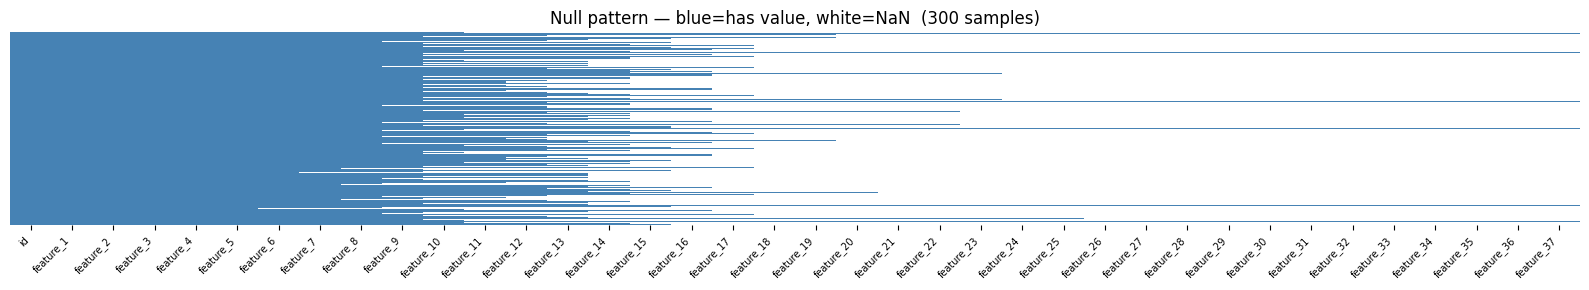


=== Meta cols unique values ===
  id: 51000 unique | top5: {'f6oqr': 1, 'cu2xz': 1, 'uv203': 1, 'rwa6i': 1, 'lzxxq': 1}
  feature_1: 120 unique | top5: {760: 8227, 685: 7919, 836: 4153, 7943: 4116, 10477: 4104}
  feature_2: 107 unique | top5: {105: 7233, 1165: 4156, 697: 4104, 1593: 4071, 2207: 4033}
  feature_3: 167 unique | top5: {8615: 8104, 105: 6848, 102: 4655, 21355: 1149, 20022: 1149}
  feature_4: 182 unique | top5: {105.0: 8864, 102.0: 5886, 103.0: 1768, 1749.0: 1724, 906.0: 1119}
  feature_5: 189 unique | top5: {103.0: 5703, 606.0: 4021, 102.0: 3623, 105.0: 2323, 694.0: 1840}
  feature_6: 193 unique | top5: {103.0: 4885, 867.0: 2428, 929.0: 2353, 24438.0: 2108, 105.0: 1728}
  feature_7: 195 unique | top5: {103.0: 4773, 105.0: 3239, 24438.0: 2615, 735.0: 2537, 697.0: 2013}


In [44]:
null_pct  = X_train.isnull().mean() * 100
meta_cols = [c for c in X_train.columns if null_pct[c] < 1.0]
seq_cols  = [c for c in X_train.columns if null_pct[c] >= 1.0]

print(f'Meta cols ({len(meta_cols)}): {meta_cols}')
print(f'Seq cols  ({len(seq_cols)}): {seq_cols[0]} ... {seq_cols[-1]}')

# Null heatmap
fig, ax = plt.subplots(figsize=(16,3))
sample = np.random.choice(len(X_train), min(300, len(X_train)), replace=False)
sns.heatmap(X_train.iloc[sample].isnull().values,
            cmap=['steelblue','white'], cbar=False, ax=ax,
            xticklabels=list(X_train.columns), yticklabels=False)
ax.set_title('Null pattern — blue=has value, white=NaN  (300 samples)')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.tight_layout(); plt.show()

# Meta cols unique values
print('\n=== Meta cols unique values ===')
for c in meta_cols:
    print(f'  {c}: {X_train[c].nunique()} unique | top5: {X_train[c].value_counts().head(5).to_dict()}')

## Convert rows → sequences

In [45]:
def row_to_seq(row):
    return [int(v) for v in row[seq_cols].dropna().values]

print('Converting sequences...')
train_seqs = X_train.apply(row_to_seq, axis=1).values
val_seqs   = X_val.apply(row_to_seq,   axis=1).values
test_seqs  = X_test.apply(row_to_seq,  axis=1).values
print(f'Done. Sample: len={len(train_seqs[0])}, values={train_seqs[0][:8]}...')

Converting sequences...
Done. Sample: len=1, values=[849]...


## Sequence Length Distribution

SEQUENCE LENGTH STATS (TRAIN)
count    51000.000000
mean         5.826294
std          4.577351
min          0.000000
10%          2.000000
25%          2.000000
50%          5.000000
75%          8.000000
90%         10.000000
95%         12.000000
99%         30.000000
max         30.000000


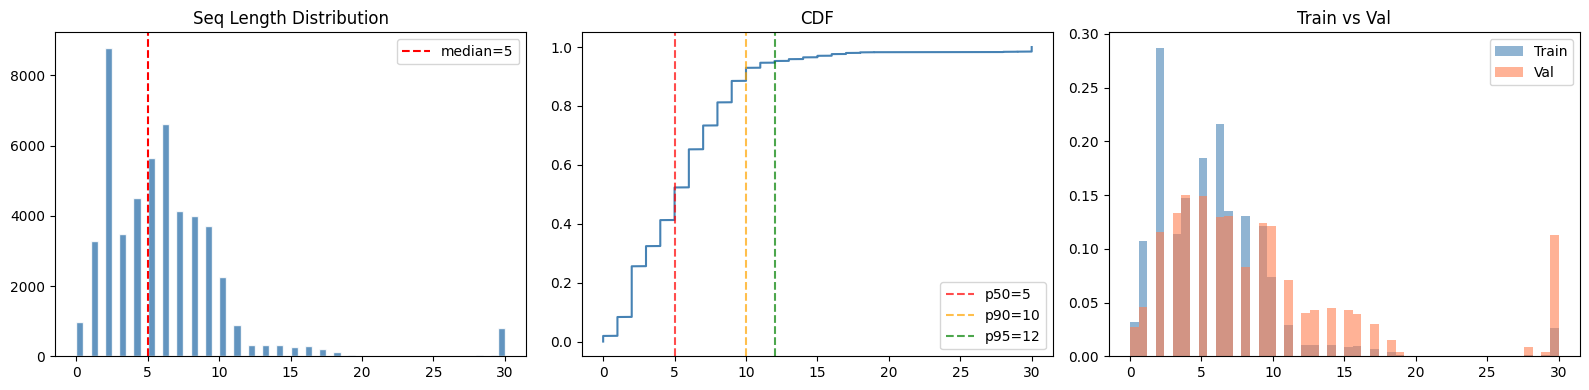


p95 length (dùng làm MAX_LEN): 12


In [46]:
lengths_tr = np.array([len(s) for s in train_seqs])
lengths_vl = np.array([len(s) for s in val_seqs])

print('SEQUENCE LENGTH STATS (TRAIN)')
print(pd.Series(lengths_tr).describe(percentiles=[.1,.25,.5,.75,.9,.95,.99]).to_string())

fig, axes = plt.subplots(1,3, figsize=(16,4))
axes[0].hist(lengths_tr, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(np.median(lengths_tr), color='red', linestyle='--', label=f'median={np.median(lengths_tr):.0f}')
axes[0].set_title('Seq Length Distribution'); axes[0].legend()

sorted_l = np.sort(lengths_tr)
axes[1].plot(sorted_l, np.arange(1,len(sorted_l)+1)/len(sorted_l), 'steelblue')
for p,c in [(50,'red'),(90,'orange'),(95,'green')]:
    xp = np.percentile(lengths_tr,p)
    axes[1].axvline(xp, color=c, linestyle='--', alpha=.7, label=f'p{p}={xp:.0f}')
axes[1].set_title('CDF'); axes[1].legend()

axes[2].hist(lengths_tr, bins=50, alpha=.6, label='Train', color='steelblue', density=True)
axes[2].hist(lengths_vl, bins=50, alpha=.6, label='Val',   color='coral',     density=True)
axes[2].set_title('Train vs Val'); axes[2].legend()
plt.tight_layout(); plt.show()

MAX_LEN_P95 = int(np.percentile(lengths_tr, 95))
print(f'\np95 length (dùng làm MAX_LEN): {MAX_LEN_P95}')

## Vocabulary Analysis

Total tokens (w/ repeat): 297,141
Unique token types:       236
Token range:              102 – 24438
Top 20: [(105, 26243), (102, 24048), (8615, 9243), (103, 8200), (697, 6852), (975, 6139), (760, 6114), (1068, 5606), (685, 5369), (21355, 4754), (15342, 4739), (21606, 4715), (17980, 4714), (21040, 4664), (20278, 4638), (20022, 4553), (15881, 4310), (1027, 4110), (995, 4104), (1080, 4100)]

Very common (>10% sessions): 9 → likely action types: [102, 103, 105, 685, 697, 760, 975, 1068, 8615]
Common (1-10%):              98
Rare (<1%):                  129 → likely product/order IDs


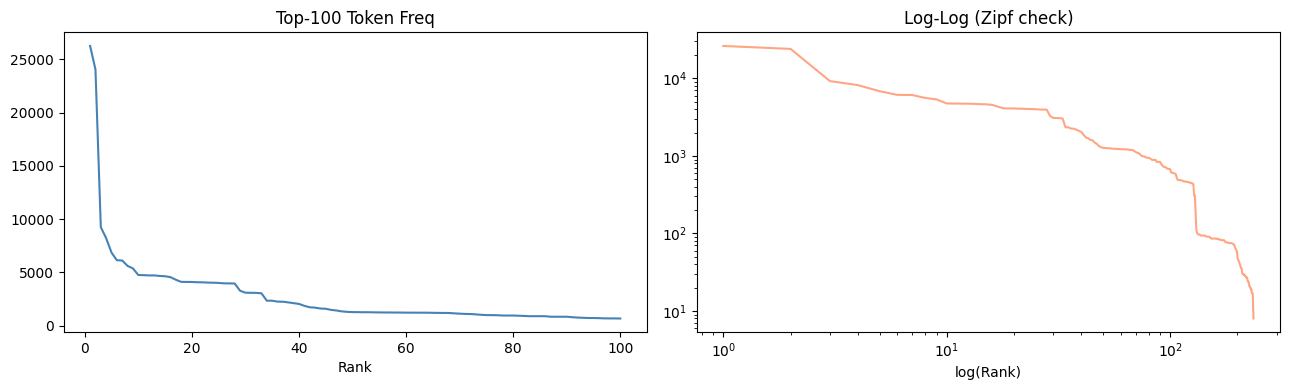

In [47]:
all_tokens    = [t for s in train_seqs for t in s]
token_counter = Counter(all_tokens)
N_train       = len(train_seqs)

print(f'Total tokens (w/ repeat): {len(all_tokens):,}')
print(f'Unique token types:       {len(token_counter):,}')
print(f'Token range:              {min(token_counter)} – {max(token_counter)}')
print(f'Top 20: {token_counter.most_common(20)}')

very_common = {t for t,f in token_counter.items() if f/N_train > 0.10}
common      = {t for t,f in token_counter.items() if 0.01 < f/N_train <= 0.10}
rare        = {t for t,f in token_counter.items() if f/N_train <= 0.01}
print(f'\nVery common (>10% sessions): {len(very_common)} → likely action types: {sorted(very_common)}')
print(f'Common (1-10%):              {len(common)}')
print(f'Rare (<1%):                  {len(rare):,} → likely product/order IDs')

freqs = sorted(token_counter.values(), reverse=True)
ranks = np.arange(1, len(freqs)+1)
fig, axes = plt.subplots(1,2, figsize=(13,4))
axes[0].plot(ranks[:100], freqs[:100], 'steelblue')
axes[0].set_title('Top-100 Token Freq'); axes[0].set_xlabel('Rank')
axes[1].loglog(ranks, freqs, 'coral', alpha=.7)
axes[1].set_title('Log-Log (Zipf check)'); axes[1].set_xlabel('log(Rank)')
plt.tight_layout(); plt.show()

## Target Distribution

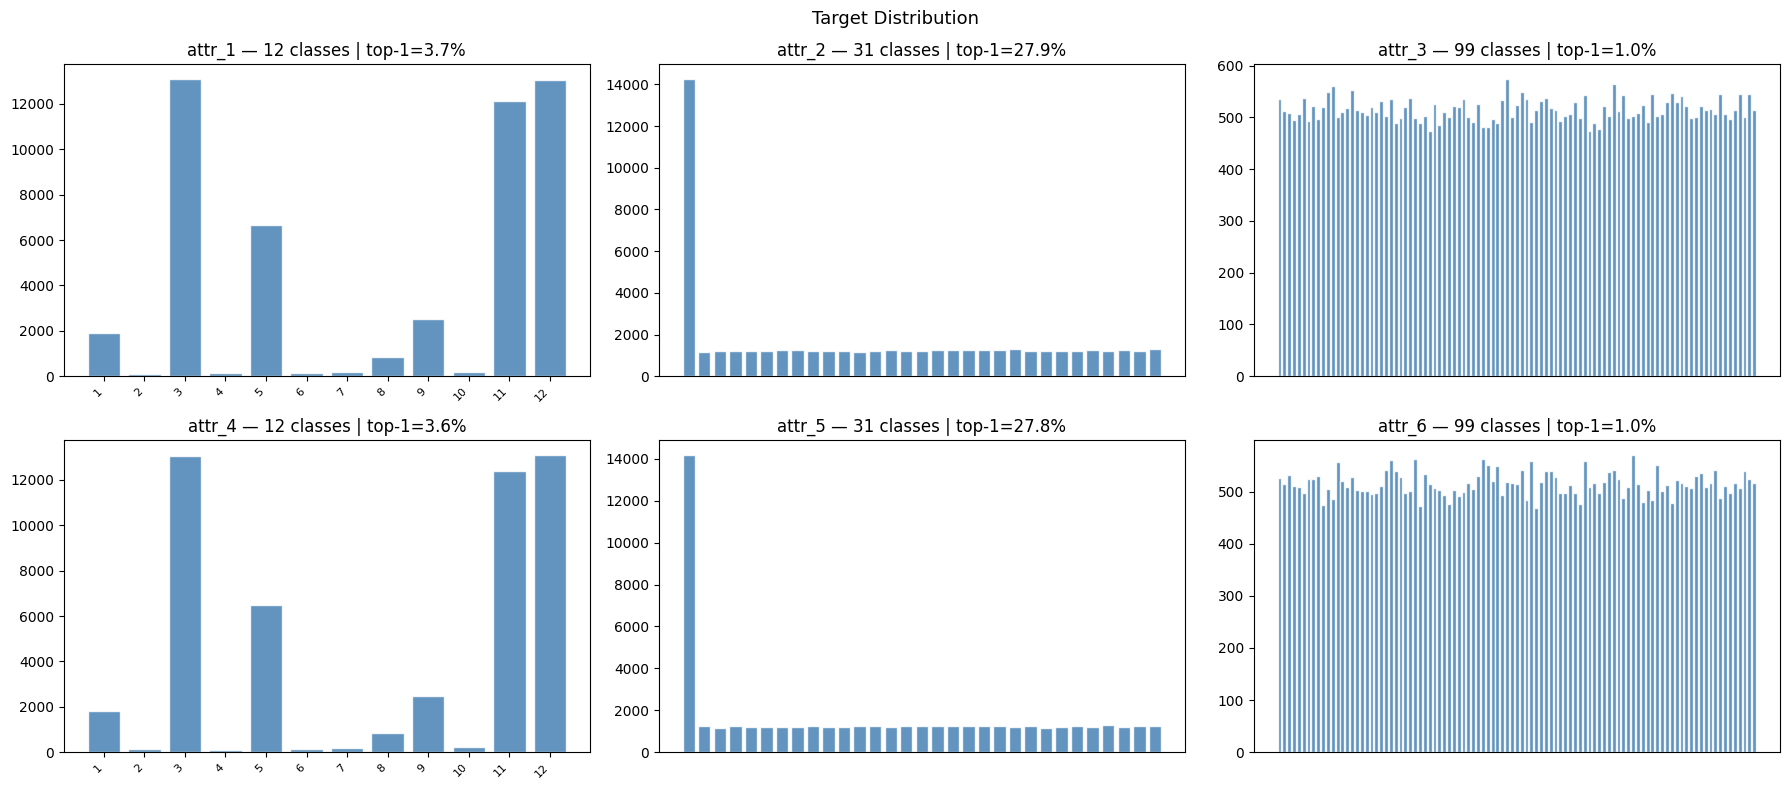

CLASS COUNT & IMBALANCE
  attr_1:  12 classes | top-1=25.7% ok
  attr_2:  31 classes | top-1=27.9% ok
  attr_3:  99 classes | top-1=1.1% ok
  attr_4:  12 classes | top-1=25.7% ok
  attr_5:  31 classes | top-1=27.8% ok
  attr_6:  99 classes | top-1=1.1% ok


In [48]:
fig, axes = plt.subplots(2,3, figsize=(18,8))
for i, col in enumerate(TARGET_COLS):
    ax = axes[i//3][i%3]
    vc = Y_train[col].value_counts().sort_index()
    ax.bar(vc.index.astype(str), vc.values, color='steelblue', edgecolor='white', alpha=.85)
    top1 = vc.iloc[0]/len(Y_train)*100
    ax.set_title(f'{col} — {Y_train[col].nunique()} classes | top-1={top1:.1f}%')
    if Y_train[col].nunique() > 20: ax.set_xticks([])
    else: plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
plt.suptitle('Target Distribution', fontsize=13)
plt.tight_layout(); plt.show()

print('CLASS COUNT & IMBALANCE')
for col in TARGET_COLS:
    vc = Y_train[col].value_counts()
    flag = 'IMBALANCED' if vc.iloc[0]/len(Y_train) > 0.5 else 'ok'
    print(f'  {col}: {Y_train[col].nunique():3d} classes | top-1={vc.iloc[0]/len(Y_train)*100:.1f}% {flag}')

## Target Correlation

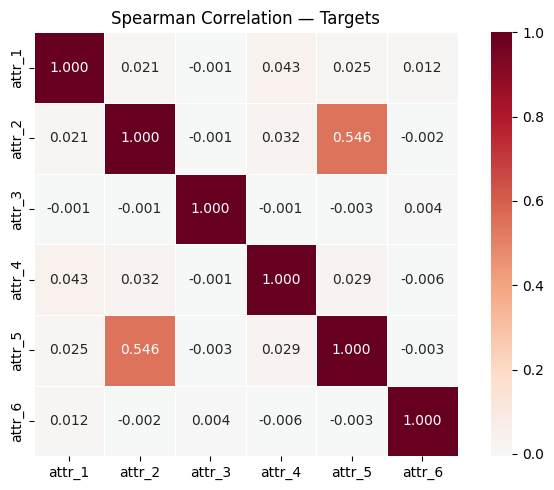

High correlation pairs (|r|>0.3):
  attr_2 ↔ attr_5: 0.546 => khai thác stacking


In [49]:
corr = Y_train[TARGET_COLS].rank().corr()
plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            square=True, linewidths=.5)
plt.title('Spearman Correlation — Targets')
plt.tight_layout(); plt.show()
print('High correlation pairs (|r|>0.3):')
for i in range(len(TARGET_COLS)):
    for j in range(i+1, len(TARGET_COLS)):
        r = corr.iloc[i,j]
        if abs(r) > 0.3:
            print(f'  {TARGET_COLS[i]} ↔ {TARGET_COLS[j]}: {r:.3f} => khai thác stacking')

## Behavioral Pattern Analysis

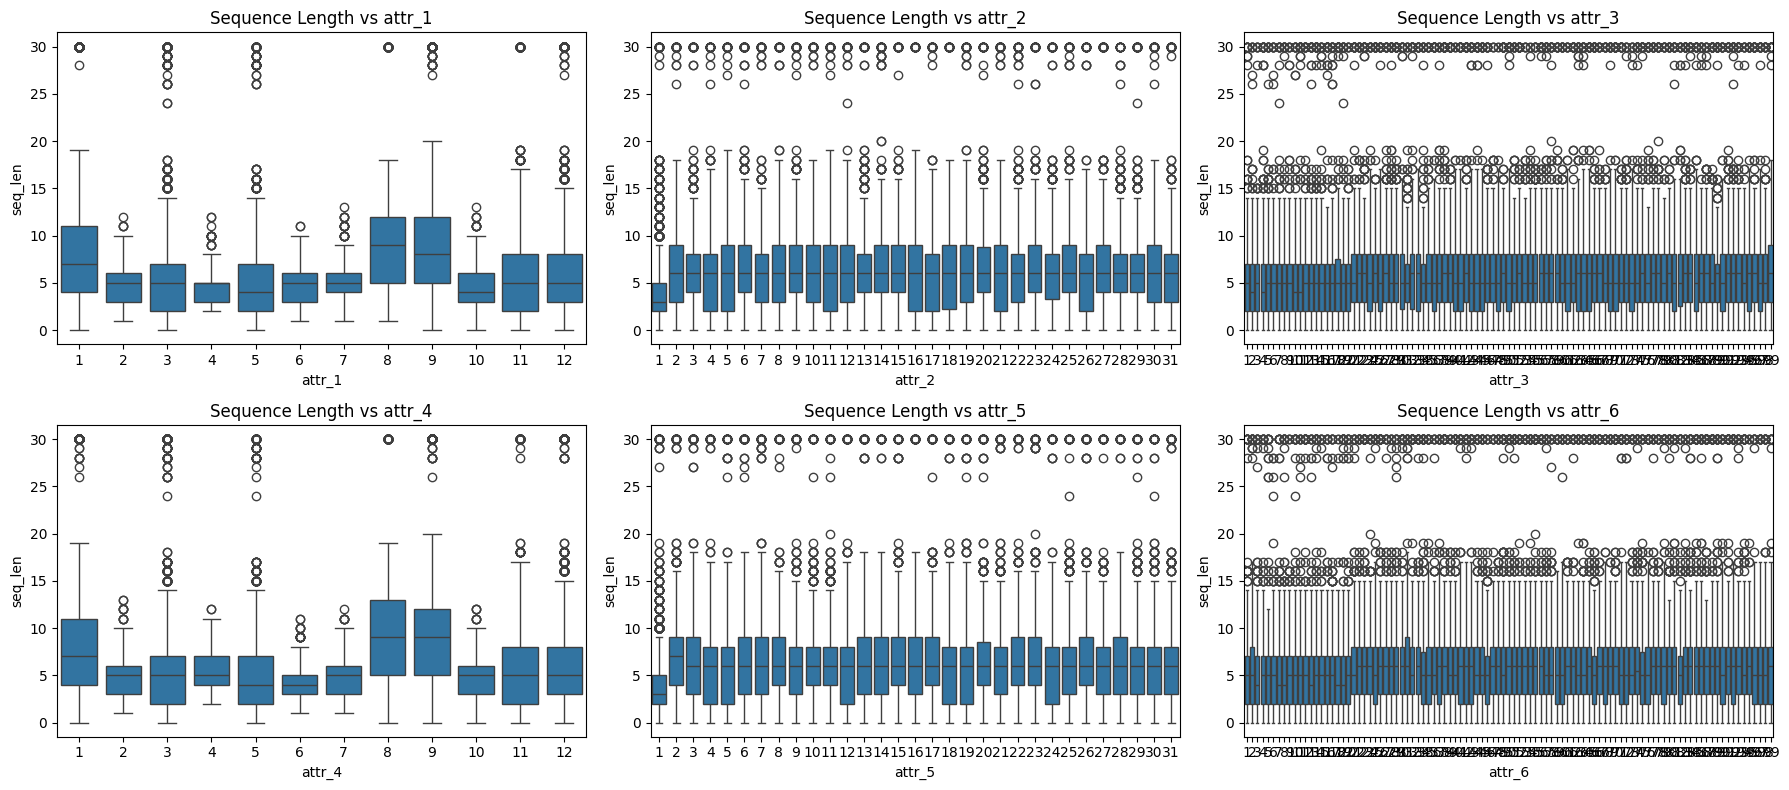

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

train_df = X_train.merge(Y_train, on="id")

train_df["seq_len"] = train_df[seq_cols].notna().sum(axis=1)

fig, axes = plt.subplots(2,3, figsize=(18,8))

for i,col in enumerate(TARGET_COLS):
    ax = axes[i//3][i%3]
    sns.boxplot(x=train_df[col], y=train_df["seq_len"], ax=ax)
    ax.set_title(f"Sequence Length vs {col}")

plt.tight_layout()

Note: sequence length có giá trị với attr_1 và attr_4, không mang nhiều ý nghĩa với attr_2 và attr_5 (box plot chồng lên nhau nhiều). attr_3 và attr_6 quá nhiều giá trị nên boxplot rối, không có giá trị phân tích

In [51]:
#Top transitions
from collections import Counter

top_transitions = Counter(pairs).most_common(20)

pd.DataFrame(top_transitions, columns=["transition","count"])

,transition,count
0,"(2207, 8615)",4049
1,"(1593, 8615)",3957
2,"(760, 1165)",3104
3,"(685, 2207)",3066
4,"(10477, 697)",3032
5,"(760, 1593)",3005
6,"(8615, 105)",2935
7,"(102, 17980)",2373
8,"(102, 21355)",2344
9,"(102, 21606)",2321


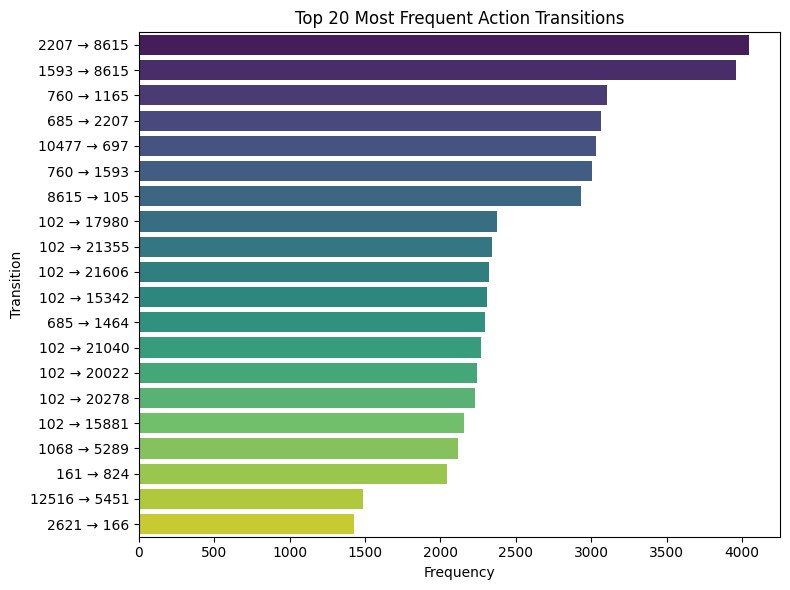

In [52]:
from collections import Counter
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# build transition pairs
pairs = [(seq[i], seq[i+1]) for seq in train_seqs for i in range(len(seq)-1)]

# count transitions
top = Counter(pairs).most_common(20)

# dataframe
top_df = pd.DataFrame(top, columns=["transition", "count"])

# convert tuple → readable string
top_df["transition"] = top_df["transition"].apply(lambda x: f"{x[0]} → {x[1]}")

# plot
plt.figure(figsize=(8,6))

sns.barplot(
    data=top_df,
    x="count",
    y="transition",
    palette="viridis"
)

plt.title("Top 20 Most Frequent Action Transitions")
plt.xlabel("Frequency")
plt.ylabel("Transition")

plt.tight_layout()

Text(0, 0.5, 'Users')

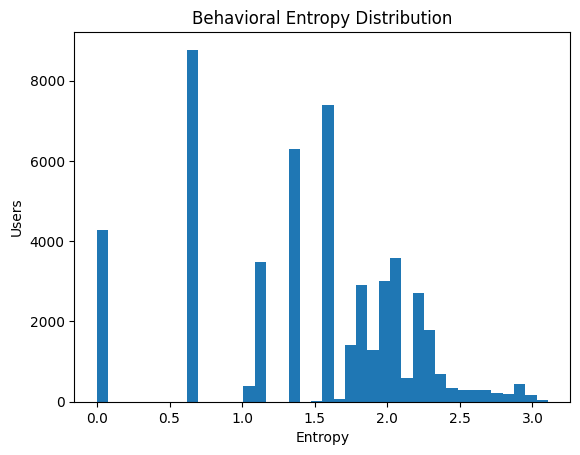

In [53]:
import scipy.stats as stats

def entropy(seq):
    if len(seq) == 0:
        return 0
    counts = np.bincount(seq)
    probs = counts / counts.sum()
    return stats.entropy(probs)

entropy_vals = [entropy(s) for s in train_seqs]

plt.hist(entropy_vals, bins=40)
plt.title("Behavioral Entropy Distribution")
plt.xlabel("Entropy")
plt.ylabel("Users")

## Analyse First and Last Action

In [54]:
# Extract first and last action
train_df["first_action"] = train_df[seq_cols].apply(
    lambda row: row.dropna().values[0] if row.notna().any() else -1,
    axis=1
)

train_df["last_action"] = train_df[seq_cols].apply(
    lambda row: row.dropna().values[-1] if row.notna().any() else -1,
    axis=1
)

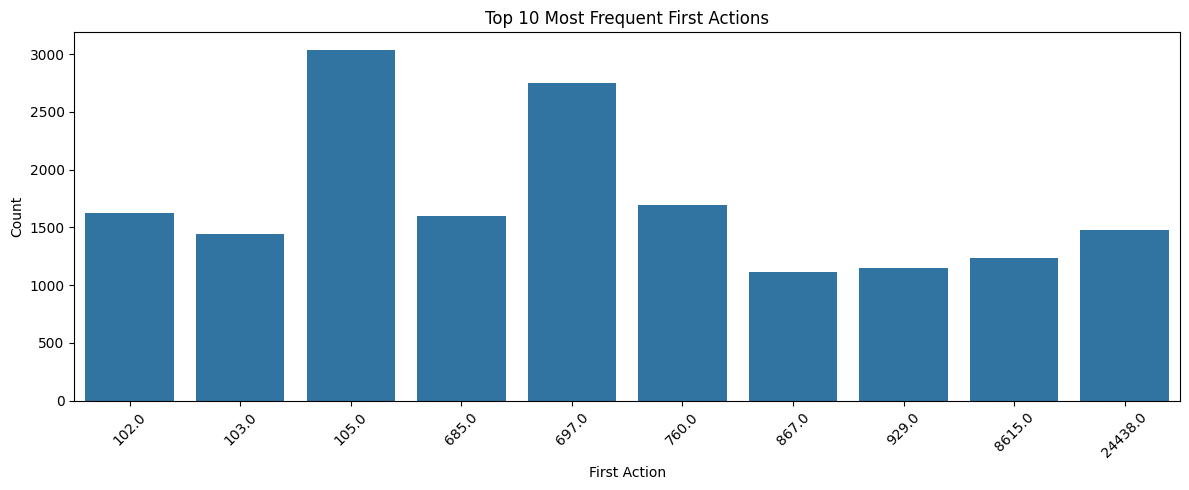

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

top_first = train_df["first_action"].value_counts().head(10)

plt.figure(figsize=(12,5))

sns.barplot(
    x=top_first.index,
    y=top_first.values
)

plt.title("Top 10 Most Frequent First Actions")
plt.xlabel("First Action")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.tight_layout()

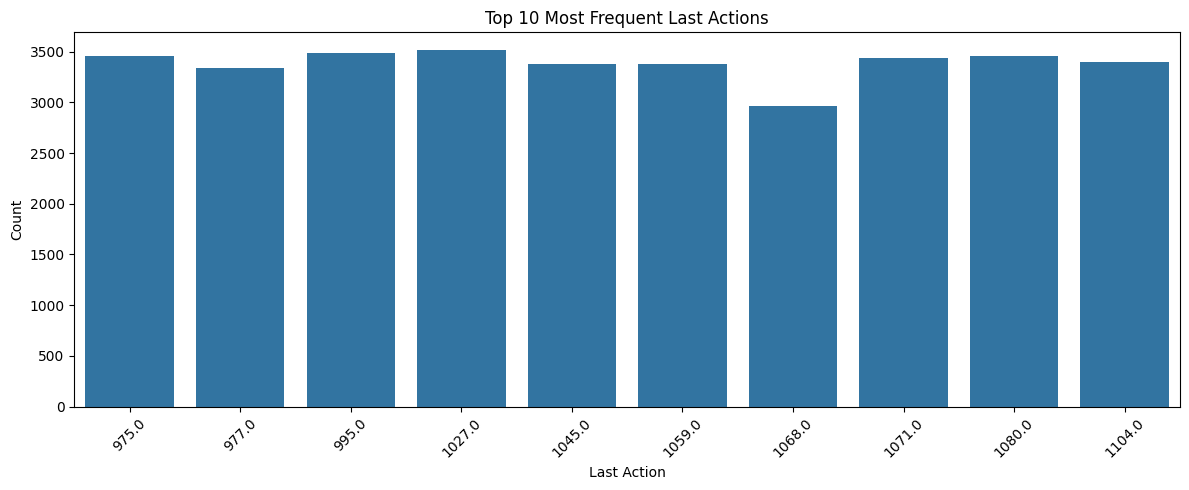

In [56]:
top_last = train_df["last_action"].value_counts().head(10)

plt.figure(figsize=(12,5))

sns.barplot(
    x=top_last.index,
    y=top_last.values
)

plt.title("Top 10 Most Frequent Last Actions")
plt.xlabel("Last Action")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.tight_layout()

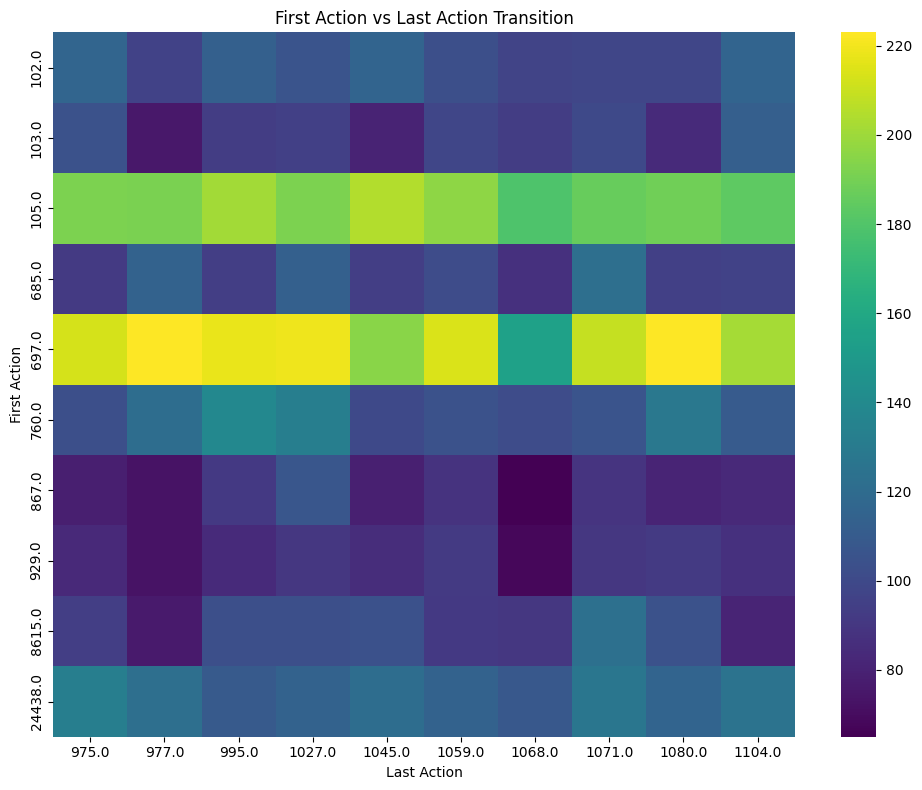

In [57]:
top_first = train_df["first_action"].value_counts().head(10).index
top_last  = train_df["last_action"].value_counts().head(10).index

subset = train_df[
    train_df["first_action"].isin(top_first) &
    train_df["last_action"].isin(top_last)
]

pivot = pd.crosstab(
    subset["first_action"],
    subset["last_action"]
)

plt.figure(figsize=(10,8))

sns.heatmap(
    pivot,
    cmap="viridis"
)

plt.title("First Action vs Last Action Transition")
plt.xlabel("Last Action")
plt.ylabel("First Action")

plt.tight_layout()

## Behavioral Personas

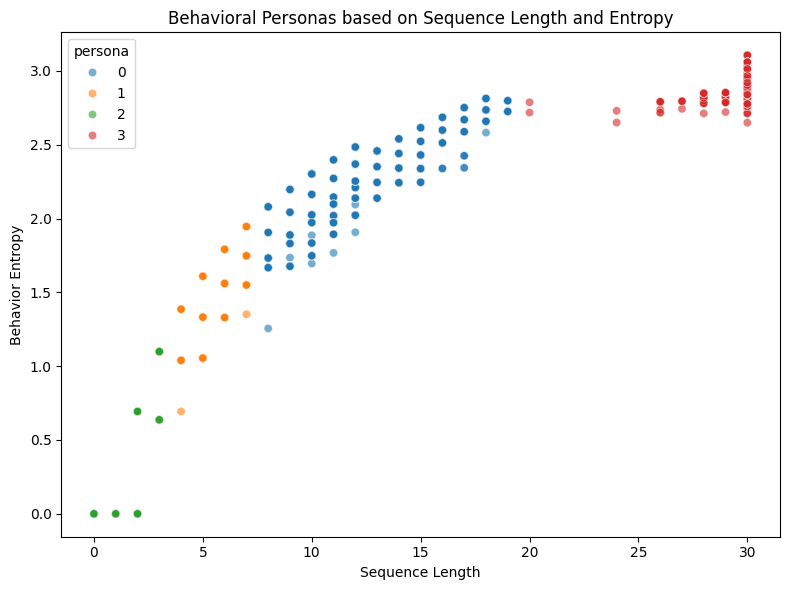

In [58]:
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

# add entropy column
train_df["entropy"] = entropy_vals

# build feature matrix for clustering
features = train_df[["seq_len", "entropy"]]

# KMeans clustering
kmeans = KMeans(n_clusters=4, random_state=42)
train_df["persona"] = kmeans.fit_predict(features)

# visualize personas
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=train_df,
    x="seq_len",
    y="entropy",
    hue="persona",
    palette="tab10",
    alpha=0.6
)

plt.title("Behavioral Personas based on Sequence Length and Entropy")
plt.xlabel("Sequence Length")
plt.ylabel("Behavior Entropy")

plt.tight_layout()

In [59]:
# Identify anomalies based on sequence length
threshold = np.percentile(lengths_tr, 99)

anomalies = train_df[train_df["seq_len"] > threshold]

print("Number of anomalous sequences:", len(anomalies))

Number of anomalous sequences: 0


## Save outputs

In [60]:
import os
import pickle

# CREATE SAVE DIRECTORY

BASE_DIR = os.getcwd()  
PIPELINE_DIR = os.path.join(BASE_DIR, "pipeline_data")

os.makedirs(PIPELINE_DIR, exist_ok=True)


# ENCODE TARGETS
from sklearn.preprocessing import LabelEncoder

encoders = {}

Y_train_enc = Y_train.copy()
Y_val_enc   = Y_val.copy()

for col in TARGET_COLS:
    le = LabelEncoder()
    Y_train_enc[col] = le.fit_transform(Y_train[col])
    Y_val_enc[col]   = le.transform(Y_val[col])
    encoders[col]    = le


# SAVE FILES
# sequences
with open(os.path.join(PIPELINE_DIR, "sequences.pkl"), "wb") as f:
    pickle.dump({
        "train": train_seqs,
        "val": val_seqs,
        "test": test_seqs
    }, f)

# metadata
with open(os.path.join(PIPELINE_DIR, "meta.pkl"), "wb") as f:
    pickle.dump({
        "meta_cols": meta_cols,
        "seq_cols": seq_cols,
        "max_len_p95": MAX_LEN_P95,
        "N_train": N_train
    }, f)

# label encoders
with open(os.path.join(PIPELINE_DIR, "encoders.pkl"), "wb") as f:
    pickle.dump(encoders, f)

# token statistics
with open(os.path.join(PIPELINE_DIR, "token_stats.pkl"), "wb") as f:
    pickle.dump({
        "counter": token_counter,
        "very_common": very_common,
        "common": common,
        "rare": rare
    }, f)

# encoded labels
Y_train_enc.to_csv(os.path.join(PIPELINE_DIR, "Y_train_enc.csv"), index=False)
Y_val_enc.to_csv(os.path.join(PIPELINE_DIR, "Y_val_enc.csv"), index=False)

# original labels
Y_train.to_csv(os.path.join(PIPELINE_DIR, "Y_train_orig.csv"), index=False)
Y_val.to_csv(os.path.join(PIPELINE_DIR, "Y_val_orig.csv"), index=False)


print("Saved pipeline outputs to:", PIPELINE_DIR)

print("""
Saved files:
   sequences.pkl
   meta.pkl
   encoders.pkl
   token_stats.pkl
   Y_train_enc.csv
   Y_val_enc.csv
   Y_train_orig.csv
   Y_val_orig.csv
""")


Saved pipeline outputs to: d:\User Behavior Analysis\pipeline_data

Saved files:
   sequences.pkl
   meta.pkl
   encoders.pkl
   token_stats.pkl
   Y_train_enc.csv
   Y_val_enc.csv
   Y_train_orig.csv
   Y_val_orig.csv

